# Global AI Startup Funding Trend Analysis (Sector/Year-wise)

## Objective
Analyze global AI startup funding trends by **sector, year, country, and funding stage**. The project identifies funding growth patterns, major AI sectors, leading countries, funding stages, and relationships between funding, valuation, employees, and investors.

### Tools Used
- **Pandas** – data loading, cleaning, transformation and analysis
- **NumPy** – numerical operations and derived categories
- **Matplotlib & Seaborn** – charts and visual analysis
- **SQL / MySQL** – database analysis
- **Power BI** – final interactive dashboard

### Dataset
Global AI startup funding records containing startup name, funding year, country, sector, funding stage, funding amount, valuation, employees and investor count.


In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Loading
Load the raw CSV dataset using Pandas.

In [ ]:
import pandas as pd

df = pd.read_csv("data/Global_AI_Startup_Funding_Raw_Dataset.csv")
+
print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (1220, 10)


,Startup_ID,Startup_Name,Funding_Year,Country,Sector,Funding_Stage,Funding_Amount_USD_Million,Valuation_USD_Million,Employees,Investors_Count
0,AI0543,Future Tech 543,2020,Singapore,Robotics,Series A,3.42,17.25,9,14
1,AI0260,Mind Intelligence 260,2020,Brazil,Agriculture AI,Series A,1.57,9.90,10,12
2,AI0044,Astra Intelligence 44,2025,Japan,Autonomous Vehicles,Series C,113.39,848.48,985,2
3,AI1011,NexGen Systems 1011,2022,Australia,Agriculture AI,Seed,0.65,2.05,8,17
4,AI0755,Orbit Systems 755,2019,France,Generative AI,Late Stage,148.08,1114.66,1044,1


## 2. Basic Dataset Exploration
Check rows, columns, data types and statistical information before cleaning.

In [5]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe(include="all"))


Rows and Columns: (1220, 10)

Column Names:
['Startup_ID', 'Startup_Name', 'Funding_Year', 'Country', 'Sector', 'Funding_Stage', 'Funding_Amount_USD_Million', 'Valuation_USD_Million', 'Employees', 'Investors_Count']

Data Types:
Startup_ID                        str
Startup_Name                      str
Funding_Year                    int64
Country                           str
Sector                            str
Funding_Stage                     str
Funding_Amount_USD_Million    float64
Valuation_USD_Million         float64
Employees                       int64
Investors_Count                 int64
dtype: object

Statistical Summary:


,Startup_ID,Startup_Name,Funding_Year,Country,Sector,Funding_Stage,Funding_Amount_USD_Million,Valuation_USD_Million,Employees,Investors_Count
count,1220,1220,1220.000000,1201,1206,1207,1212.000000,1220.000000,1220.000000,1220.000000
unique,1200,1200,NaN,18,18,7,NaN,NaN,NaN,NaN
top,AI0129,Orbit Tech 129,NaN,South Korea,EdTech AI,Seed,NaN,NaN,NaN,NaN
freq,2,2,NaN,94,99,304,NaN,NaN,NaN,NaN
mean,NaN,NaN,2021.478689,NaN,NaN,NaN,28.735470,211.898730,300.278689,9.293443
std,NaN,NaN,2.305332,NaN,NaN,NaN,62.140784,493.241677,765.126455,4.843993
min,NaN,NaN,2018.000000,NaN,NaN,NaN,-16.170000,0.520000,3.000000,1.000000
25%,NaN,NaN,2019.000000,NaN,NaN,NaN,1.050000,7.532500,13.000000,5.000000
50%,NaN,NaN,2021.000000,NaN,NaN,NaN,5.525000,38.830000,43.000000,10.000000
75%,NaN,NaN,2023.000000,NaN,NaN,NaN,25.965000,170.902500,209.000000,13.000000


## 3. Data Cleaning

### Operations performed
1. Remove extra spaces from column names and text values.
2. Convert numeric columns to numeric types.
3. Standardize inconsistent sector names.
4. Check and handle missing values.
5. Convert negative funding values to missing values.
6. Remove duplicate records.
7. Verify the cleaned dataset.


In [6]:
# 3.1 Clean column names
df.columns = df.columns.str.strip()

# 3.2 Strip whitespace from text columns
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 3.3 Convert numeric columns
numeric_cols = [
    "Funding_Year", "Funding_Amount_USD_Million",
    "Valuation_USD_Million", "Employees", "Investors_Count"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3.4 Standardize sector names
sector_map = {
    "Gen AI": "Generative AI",
    "Healthcare-AI": "Healthcare AI",
    "Fin Tech AI": "FinTech AI"
}
df["Sector"] = df["Sector"].replace(sector_map)

# 3.5 Strip/standardize country names
df["Country"] = df["Country"].str.strip()

# 3.6 Invalid negative funding -> missing
df.loc[df["Funding_Amount_USD_Million"] < 0, "Funding_Amount_USD_Million"] = np.nan

print("Missing values before filling:")
display(df.isnull().sum())

print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates()

# 3.7 Fill categorical missing values
for col in ["Country", "Sector", "Funding_Stage"]:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# 3.8 Fill numeric missing values with median
for col in ["Funding_Amount_USD_Million", "Valuation_USD_Million", "Employees", "Investors_Count"]:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("\nCleaning completed.")
print("Final shape:", df.shape)
display(df.head())


Missing values before filling:


C:\Users\Admin\AppData\Local\Temp\ipykernel_20908\2448821877.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


Startup_ID                     0
Startup_Name                   0
Funding_Year                   0
Country                       19
Sector                        14
Funding_Stage                 13
Funding_Amount_USD_Million    13
Valuation_USD_Million          0
Employees                      0
Investors_Count                0
dtype: int64

Duplicate rows before removal: 19

Cleaning completed.
Final shape: (1201, 10)


,Startup_ID,Startup_Name,Funding_Year,Country,Sector,Funding_Stage,Funding_Amount_USD_Million,Valuation_USD_Million,Employees,Investors_Count
0,AI0543,Future Tech 543,2020,Singapore,Robotics,Series A,3.42,17.25,9,14
1,AI0260,Mind Intelligence 260,2020,Brazil,Agriculture AI,Series A,1.57,9.90,10,12
2,AI0044,Astra Intelligence 44,2025,Japan,Autonomous Vehicles,Series C,113.39,848.48,985,2
3,AI1011,NexGen Systems 1011,2022,Australia,Agriculture AI,Seed,0.65,2.05,8,17
4,AI0755,Orbit Systems 755,2019,France,Generative AI,Late Stage,148.08,1114.66,1044,1


## 4. NumPy Operation
Create a funding-size category using the median funding amount.

In [7]:
median_funding = df["Funding_Amount_USD_Million"].median()

df["Funding_Size"] = np.where(
    df["Funding_Amount_USD_Million"] >= median_funding,
    "High Funding",
    "Low Funding"
)

print("Median Funding:", round(median_funding, 2), "Million USD")
display(df[["Startup_Name", "Funding_Amount_USD_Million", "Funding_Size"]].head())


Median Funding: 5.52 Million USD


,Startup_Name,Funding_Amount_USD_Million,Funding_Size
0,Future Tech 543,3.42,Low Funding
1,Mind Intelligence 260,1.57,Low Funding
2,Astra Intelligence 44,113.39,High Funding
3,NexGen Systems 1011,0.65,Low Funding
4,Orbit Systems 755,148.08,High Funding


## 5. Create Derived Columns
Create useful measures for analysis and dashboarding.

In [8]:
df["Funding_Per_Employee"] = (
    df["Funding_Amount_USD_Million"] * 1_000_000
) / df["Employees"]

df["Valuation_to_Funding_Ratio"] = (
    df["Valuation_USD_Million"] / df["Funding_Amount_USD_Million"]
)

df["Funding_Per_Investor"] = (
    df["Funding_Amount_USD_Million"] / df["Investors_Count"]
)

display(df.head())


,Startup_ID,Startup_Name,Funding_Year,Country,Sector,Funding_Stage,Funding_Amount_USD_Million,Valuation_USD_Million,Employees,Investors_Count,Funding_Size,Funding_Per_Employee,Valuation_to_Funding_Ratio,Funding_Per_Investor
0,AI0543,Future Tech 543,2020,Singapore,Robotics,Series A,3.42,17.25,9,14,Low Funding,380000.000000,5.043860,0.244286
1,AI0260,Mind Intelligence 260,2020,Brazil,Agriculture AI,Series A,1.57,9.90,10,12,Low Funding,157000.000000,6.305732,0.130833
2,AI0044,Astra Intelligence 44,2025,Japan,Autonomous Vehicles,Series C,113.39,848.48,985,2,High Funding,115116.751269,7.482847,56.695000
3,AI1011,NexGen Systems 1011,2022,Australia,Agriculture AI,Seed,0.65,2.05,8,17,Low Funding,81250.000000,3.153846,0.038235
4,AI0755,Orbit Systems 755,2019,France,Generative AI,Late Stage,148.08,1114.66,1044,1,High Funding,141839.080460,7.527418,148.080000


## 6. Save Cleaned Dataset

In [9]:
df.to_csv("data/global_ai_startup_funding_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.


## 7. Exploratory Data Analysis (EDA)

In [10]:
print("Final Shape:", df.shape)
print("Number of Startups:", df["Startup_ID"].nunique())
print("Countries:", df["Country"].nunique())
print("Sectors:", df["Sector"].nunique())
print("Funding Stages:", df["Funding_Stage"].nunique())
print("Years:", sorted(df["Funding_Year"].unique()))

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Final Shape: (1201, 14)
Number of Startups: 1200
Countries: 16
Sectors: 15
Funding Stages: 7
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Missing values:


Startup_ID                    0
Startup_Name                  0
Funding_Year                  0
Country                       0
Sector                        0
Funding_Stage                 0
Funding_Amount_USD_Million    0
Valuation_USD_Million         0
Employees                     0
Investors_Count               0
Funding_Size                  0
Funding_Per_Employee          0
Valuation_to_Funding_Ratio    0
Funding_Per_Investor          0
dtype: int64


Duplicate rows:
0


## 8. Sector-wise Funding Analysis

In [11]:
sector_summary = df.groupby("Sector", as_index=False).agg(
    Total_Funding_USD_Million=("Funding_Amount_USD_Million", "sum"),
    Average_Funding_USD_Million=("Funding_Amount_USD_Million", "mean"),
    Startup_Count=("Startup_ID", "nunique")
).sort_values("Total_Funding_USD_Million", ascending=False)

display(sector_summary)


,Sector,Total_Funding_USD_Million,Average_Funding_USD_Million,Startup_Count
5,Cybersecurity AI,3072.400,36.576190,84
8,Generative AI,3061.215,36.014294,85
6,EdTech AI,2995.775,26.747991,112
2,Autonomous Vehicles,2663.460,30.614483,87
14,Robotics,2500.010,28.409205,88
10,Legal AI,2408.065,30.481835,78
1,Agriculture AI,2282.450,31.266438,73
3,Climate AI,2281.270,25.632247,89
9,Healthcare AI,2267.930,26.999167,84
4,Computer Vision,2232.100,27.901250,80


## 9. Year-wise AI Startup Funding Trend

In [12]:
year_summary = df.groupby("Funding_Year", as_index=False).agg(
    Total_Funding_USD_Million=("Funding_Amount_USD_Million", "sum"),
    Average_Funding_USD_Million=("Funding_Amount_USD_Million", "mean"),
    Startup_Count=("Startup_ID", "nunique")
).sort_values("Funding_Year")

display(year_summary)


,Funding_Year,Total_Funding_USD_Million,Average_Funding_USD_Million,Startup_Count
0,2018,2895.570,17.984907,161
1,2019,2792.140,19.389861,144
2,2020,3414.875,24.218972,141
3,2021,4323.270,26.852609,161
4,2022,3772.385,24.027930,156
5,2023,5175.725,37.505254,138
6,2024,5112.470,35.751538,143
7,2025,6521.230,41.802756,156


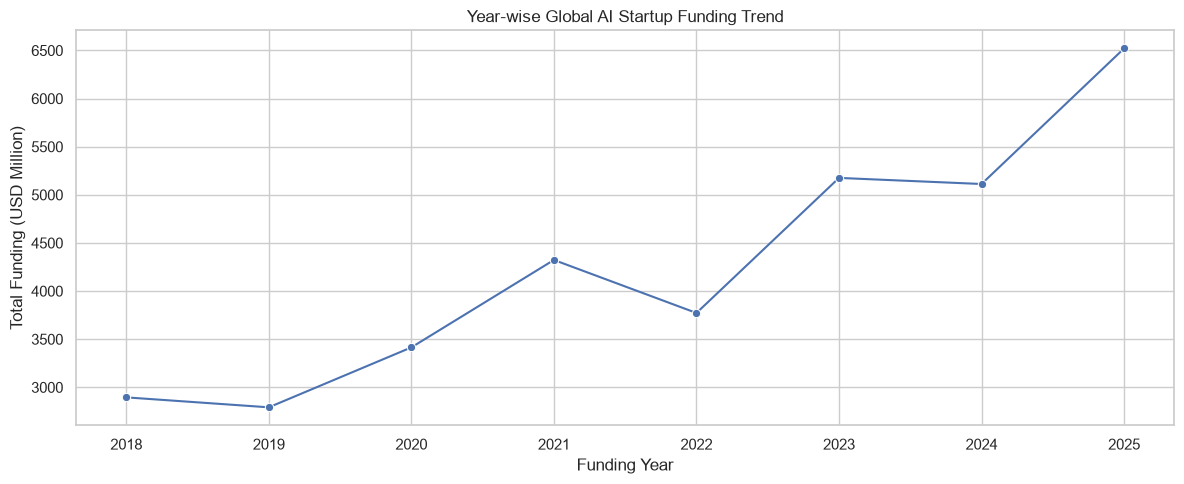

In [13]:
plt.figure(figsize=(12,5))
sns.lineplot(data=year_summary, x="Funding_Year", y="Total_Funding_USD_Million", marker="o")
plt.title("Year-wise Global AI Startup Funding Trend")
plt.xlabel("Funding Year")
plt.ylabel("Total Funding (USD Million)")
plt.tight_layout()
plt.show()


## 10. Sector-wise Funding Trend by Year

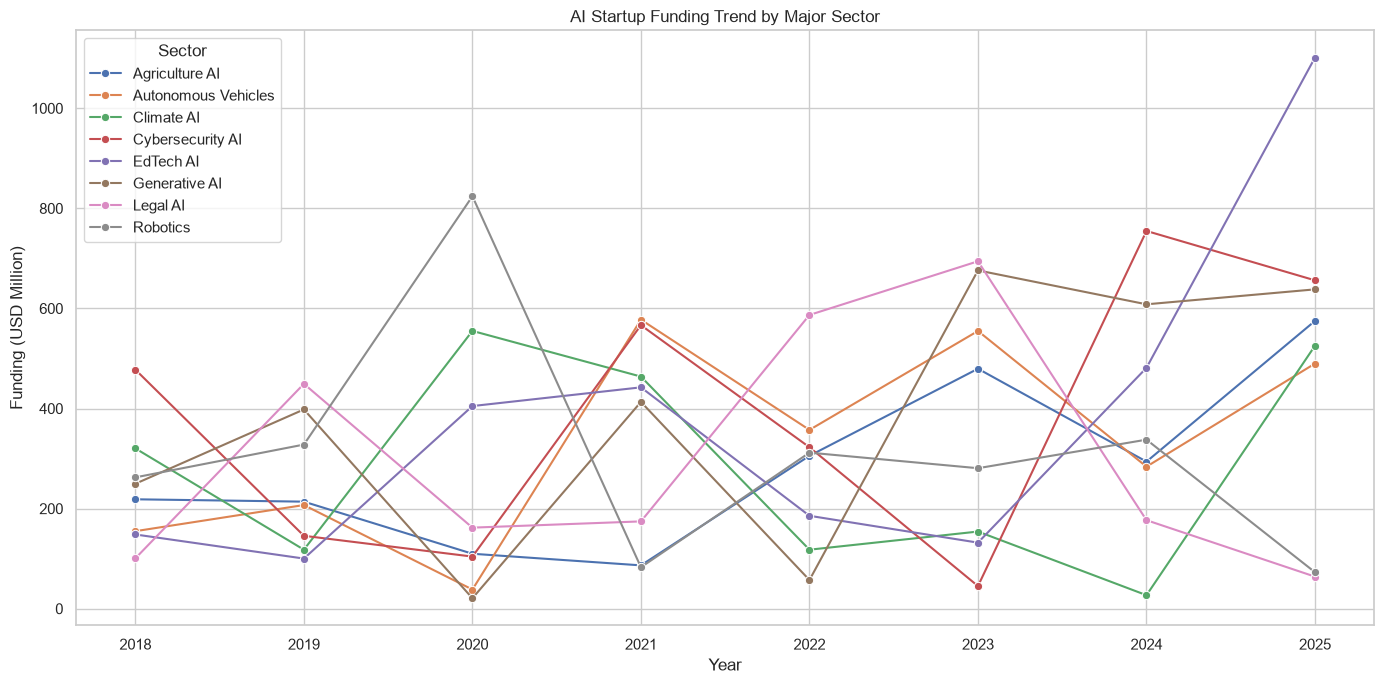

In [14]:
sector_year = df.groupby(["Funding_Year", "Sector"], as_index=False)[
    "Funding_Amount_USD_Million"
].sum()

top_sectors = (
    sector_year.groupby("Sector")["Funding_Amount_USD_Million"]
    .sum()
    .nlargest(8)
    .index
)

plt.figure(figsize=(14,7))
sns.lineplot(
    data=sector_year[sector_year["Sector"].isin(top_sectors)],
    x="Funding_Year",
    y="Funding_Amount_USD_Million",
    hue="Sector",
    marker="o"
)
plt.title("AI Startup Funding Trend by Major Sector")
plt.xlabel("Year")
plt.ylabel("Funding (USD Million)")
plt.tight_layout()
plt.show()


## 11. Funding Stage Analysis

,Funding_Stage,Total_Funding_USD_Million,Average_Funding_USD_Million,Startup_Count
0,Late Stage,14692.050,179.171341,82
6,Series D,8027.100,97.891463,82
5,Series C,4760.660,41.040172,116
4,Series B,3906.505,20.346380,192
3,Series A,1909.775,6.772252,281
2,Seed,647.955,2.070144,313
1,Pre-Seed,63.620,0.474776,134


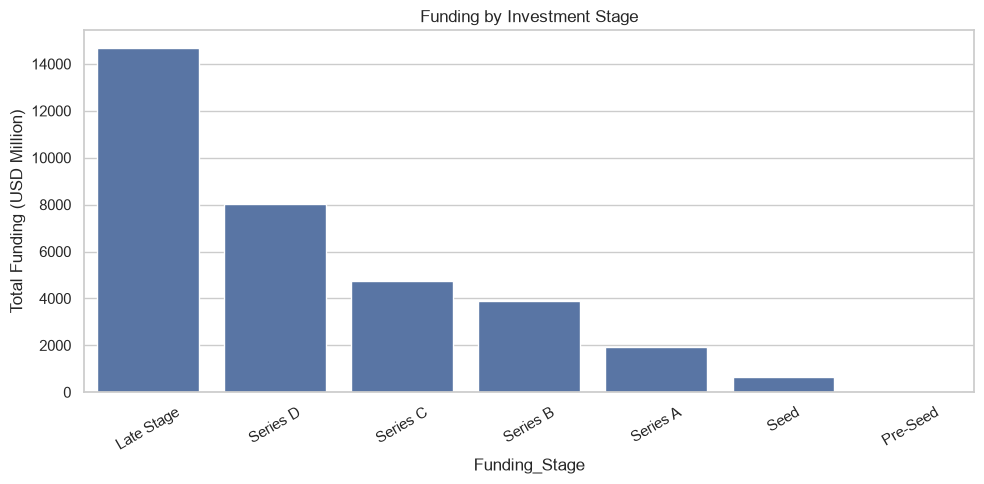

In [15]:
stage_summary = df.groupby("Funding_Stage", as_index=False).agg(
    Total_Funding_USD_Million=("Funding_Amount_USD_Million", "sum"),
    Average_Funding_USD_Million=("Funding_Amount_USD_Million", "mean"),
    Startup_Count=("Startup_ID", "nunique")
).sort_values("Total_Funding_USD_Million", ascending=False)

display(stage_summary)

plt.figure(figsize=(10,5))
sns.barplot(data=stage_summary, x="Funding_Stage", y="Total_Funding_USD_Million")
plt.title("Funding by Investment Stage")
plt.xticks(rotation=30)
plt.ylabel("Total Funding (USD Million)")
plt.tight_layout()
plt.show()


## 12. Country-wise AI Startup Funding Analysis

In [16]:
country_summary = df.groupby("Country", as_index=False).agg(
    Total_Funding_USD_Million=("Funding_Amount_USD_Million", "sum"),
    Startup_Count=("Startup_ID", "nunique"),
    Average_Funding_USD_Million=("Funding_Amount_USD_Million", "mean")
).sort_values("Total_Funding_USD_Million", ascending=False)

display(country_summary)


,Country,Total_Funding_USD_Million,Startup_Count,Average_Funding_USD_Million
9,Netherlands,2927.060,80,36.588250
10,Singapore,2851.920,69,41.332174
8,Japan,2772.780,63,44.012381
11,South Korea,2704.745,111,24.367072
2,Canada,2425.635,83,28.876607
12,Switzerland,2328.735,72,32.343542
13,UAE,2288.255,81,28.250062
6,India,2273.225,76,29.910855
4,France,2103.445,67,31.394701
1,Brazil,2047.775,69,29.677899


## 13. Top 10 Countries by Total Funding

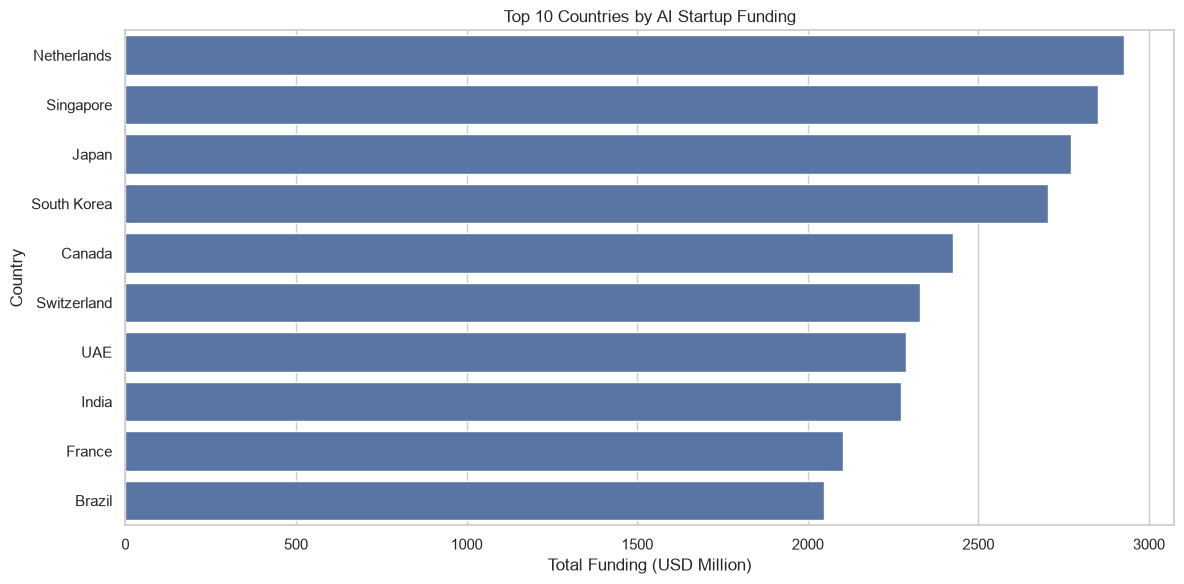

In [17]:
top_countries = country_summary.head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_countries, y="Country", x="Total_Funding_USD_Million")
plt.title("Top 10 Countries by AI Startup Funding")
plt.xlabel("Total Funding (USD Million)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## 14. Top 10 AI Startups by Funding

In [18]:
top_startups = df.nlargest(10, "Funding_Amount_USD_Million")[
    ["Startup_Name", "Country", "Sector", "Funding_Stage", "Funding_Amount_USD_Million"]
]
display(top_startups)


,Startup_Name,Country,Sector,Funding_Stage,Funding_Amount_USD_Million
1024,Alpha AI 897,Singapore,NLP,Late Stage,732.34
174,Vertex Intelligence 1147,Singapore,Generative AI,Late Stage,557.80
1215,NexGen Systems 1045,Switzerland,Legal AI,Late Stage,536.69
626,Orbit Labs 842,UAE,AI Infrastructure,Late Stage,463.12
1131,Data Tech 419,Brazil,Generative AI,Late Stage,431.63
959,Mind Robotics 883,Japan,Robotics,Late Stage,429.54
339,Alpha Tech 212,South Korea,Cybersecurity AI,Late Stage,423.69
89,Intelli Intelligence 948,Netherlands,EdTech AI,Late Stage,361.77
193,Core Analytics 1001,India,Agriculture AI,Late Stage,338.61
1095,Deep Systems 96,Switzerland,Generative AI,Late Stage,337.95


## 15. Sector-wise Startup Count

,Sector,Startup_Count
0,EdTech AI,112
1,Climate AI,89
2,Robotics,88
3,Autonomous Vehicles,87
4,Generative AI,85
5,Cybersecurity AI,84
6,Healthcare AI,84
7,Computer Vision,80
8,Legal AI,79
9,FinTech AI,79


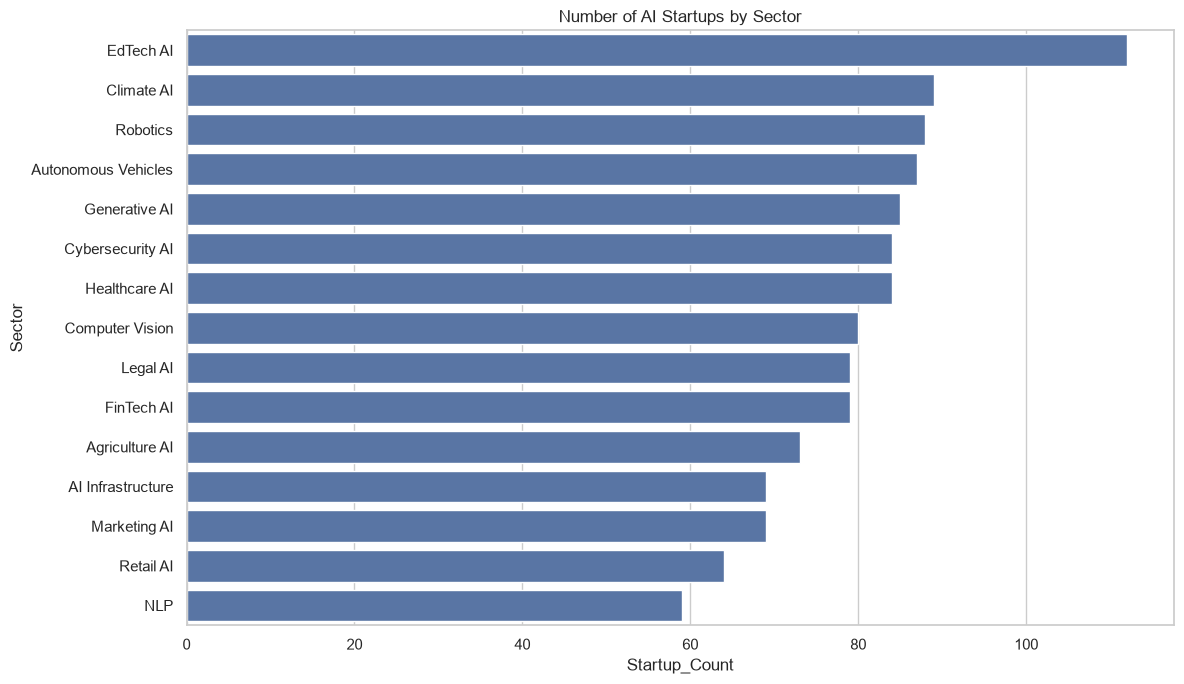

In [19]:
sector_count = df["Sector"].value_counts().reset_index()
sector_count.columns = ["Sector", "Startup_Count"]
display(sector_count)

plt.figure(figsize=(12,7))
sns.barplot(data=sector_count, y="Sector", x="Startup_Count")
plt.title("Number of AI Startups by Sector")
plt.tight_layout()
plt.show()


## 16. Average Funding by Sector

In [20]:
avg_sector = df.groupby("Sector", as_index=False)[
    "Funding_Amount_USD_Million"
].mean().sort_values("Funding_Amount_USD_Million", ascending=False)

display(avg_sector)


,Sector,Funding_Amount_USD_Million
5,Cybersecurity AI,36.576190
8,Generative AI,36.014294
1,Agriculture AI,31.266438
12,NLP,31.168220
2,Autonomous Vehicles,30.614483
10,Legal AI,30.481835
14,Robotics,28.409205
4,Computer Vision,27.901250
13,Retail AI,27.437344
9,Healthcare AI,26.999167


## 17. Funding Distribution

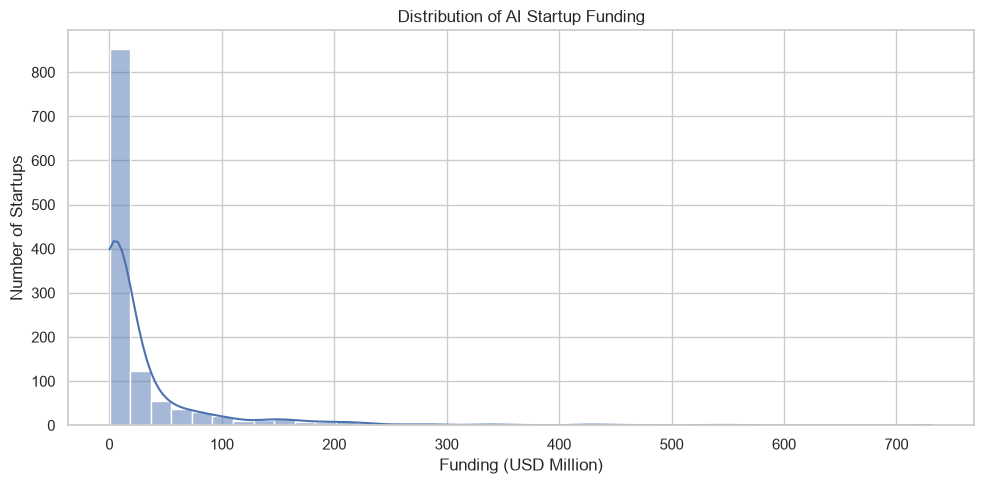

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df["Funding_Amount_USD_Million"], bins=40, kde=True)
plt.title("Distribution of AI Startup Funding")
plt.xlabel("Funding (USD Million)")
plt.ylabel("Number of Startups")
plt.tight_layout()
plt.show()


## 18. Funding vs Valuation

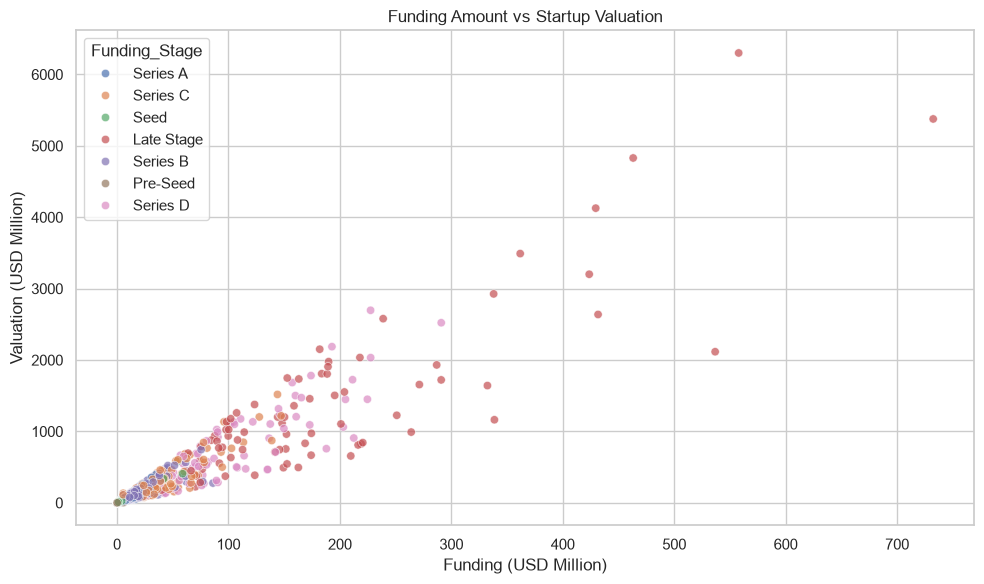

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Funding_Amount_USD_Million",
    y="Valuation_USD_Million",
    hue="Funding_Stage",
    alpha=0.7
)
plt.title("Funding Amount vs Startup Valuation")
plt.xlabel("Funding (USD Million)")
plt.ylabel("Valuation (USD Million)")
plt.tight_layout()
plt.show()


## 19. Correlation Analysis

In [23]:
corr_cols = [
    "Funding_Amount_USD_Million",
    "Valuation_USD_Million",
    "Employees",
    "Investors_Count",
    "Funding_Per_Employee",
    "Valuation_to_Funding_Ratio",
    "Funding_Per_Investor"
]

correlation = df[corr_cols].corr()
display(correlation)


,Funding_Amount_USD_Million,Valuation_USD_Million,Employees,Investors_Count,Funding_Per_Employee,Valuation_to_Funding_Ratio,Funding_Per_Investor
Funding_Amount_USD_Million,1.000000,0.935687,0.802563,-0.051716,0.016609,-0.017235,0.657033
Valuation_USD_Million,0.935687,1.000000,0.737876,-0.052020,0.019935,0.130992,0.606211
Employees,0.802563,0.737876,1.000000,-0.051586,-0.132373,-0.035478,0.571525
Investors_Count,-0.051716,-0.052020,-0.051586,1.000000,-0.023862,-0.018746,-0.293210
Funding_Per_Employee,0.016609,0.019935,-0.132373,-0.023862,1.000000,-0.068359,0.001640
Valuation_to_Funding_Ratio,-0.017235,0.130992,-0.035478,-0.018746,-0.068359,1.000000,-0.008407
Funding_Per_Investor,0.657033,0.606211,0.571525,-0.293210,0.001640,-0.008407,1.000000


## 20. Correlation Heatmap

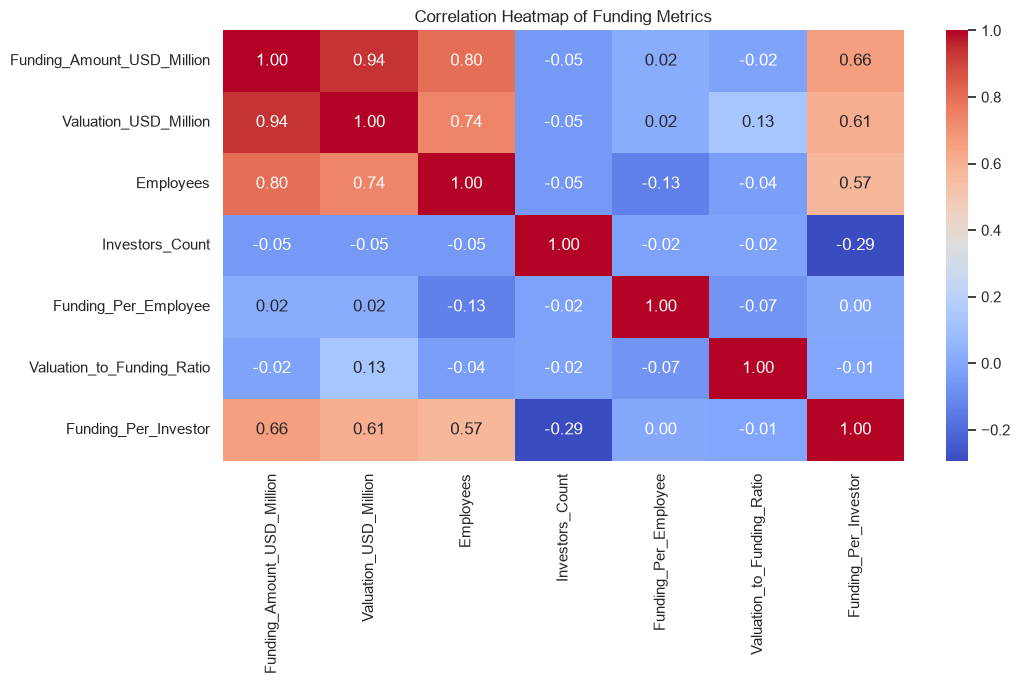

In [24]:
plt.figure(figsize=(11,7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Funding Metrics")
plt.tight_layout()
plt.show()


## 21. Funding Size Distribution

,Funding_Size,Startup_Count
0,High Funding,607
1,Low Funding,594


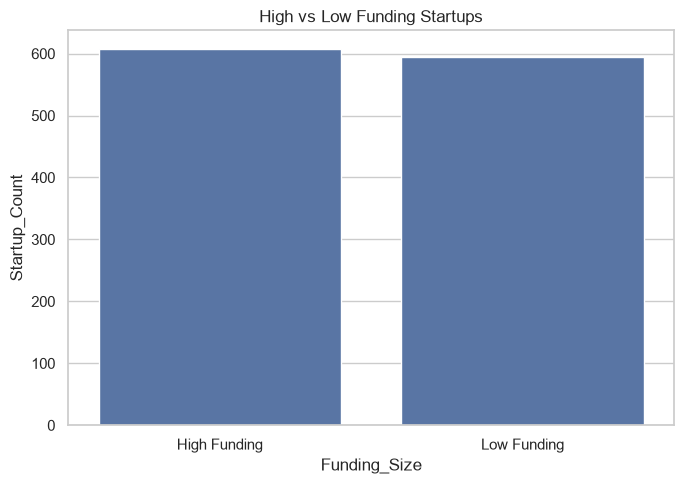

In [25]:
funding_size = df["Funding_Size"].value_counts().reset_index()
funding_size.columns = ["Funding_Size", "Startup_Count"]
display(funding_size)

plt.figure(figsize=(7,5))
sns.barplot(data=funding_size, x="Funding_Size", y="Startup_Count")
plt.title("High vs Low Funding Startups")
plt.tight_layout()
plt.show()


## 22. Key Business Insights


In [26]:
highest_sector = sector_summary.iloc[0]
highest_year = year_summary.loc[year_summary["Total_Funding_USD_Million"].idxmax()]
highest_country = country_summary.iloc[0]
highest_stage = stage_summary.iloc[0]
top_startup = df.loc[df["Funding_Amount_USD_Million"].idxmax()]

print("Key Insights")
print("-" * 60)
print(f"Highest funded sector: {highest_sector['Sector']}")
print(f"Total funding in this sector: ${highest_sector['Total_Funding_USD_Million']:.2f}M")
print(f"Highest funding year: {int(highest_year['Funding_Year'])}")
print(f"Funding in that year: ${highest_year['Total_Funding_USD_Million']:.2f}M")
print(f"Highest funded country: {highest_country['Country']}")
print(f"Country funding: ${highest_country['Total_Funding_USD_Million']:.2f}M")
print(f"Highest funding stage by total funding: {highest_stage['Funding_Stage']}")
print(f"Top individual startup by funding: {top_startup['Startup_Name']}")


Key Insights
------------------------------------------------------------
Highest funded sector: Cybersecurity AI
Total funding in this sector: $3072.40M
Highest funding year: 2025
Funding in that year: $6521.23M
Highest funded country: Netherlands
Country funding: $2927.06M
Highest funding stage by total funding: Late Stage
Top individual startup by funding: Alpha AI 897


## 23. Final Validation

In [27]:
print("Final rows:", len(df))
print("Final columns:", len(df.columns))
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("\nProject notebook validation completed successfully.")


Final rows: 1201
Final columns: 14
Missing values: 0
Duplicate rows: 0

Project notebook validation completed successfully.
